Using Colab cache for faster access to the 'household-power-consumption' dataset.
Found file at: /kaggle/input/household-power-consumption/household_power_consumption.csv


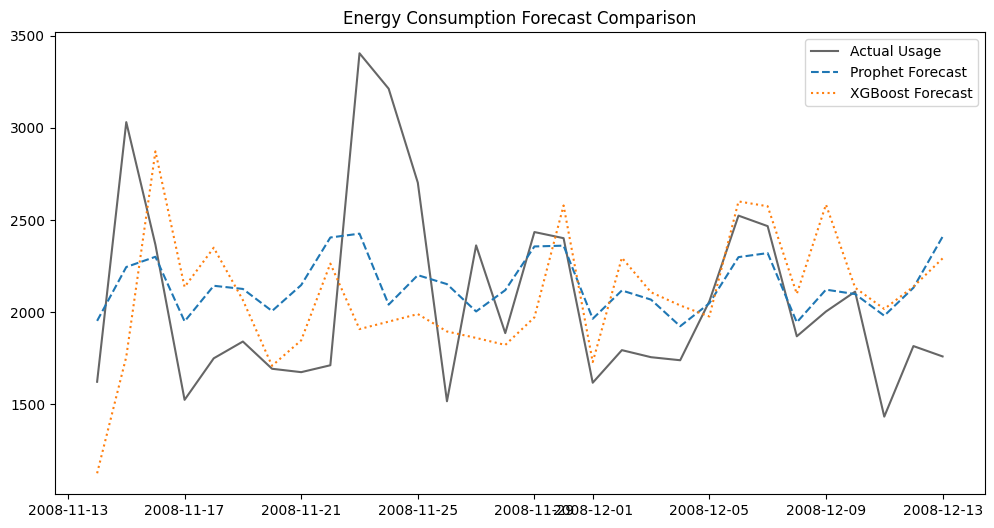

Prophet MAE: 368.08
XGBoost MAE: 444.10


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub
import glob
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. DOWNLOAD AND LOAD DATASET
path = kagglehub.dataset_download("imtkaggleteam/household-power-consumption")

# Find the file
files = glob.glob(os.path.join(path, "*.txt")) + glob.glob(os.path.join(path, "*.csv"))
csv_path = files[0]
print(f"Found file at: {csv_path}")

# Load dataset - Try comma first, then semicolon if it fails to find 'Date'
try:
    df = pd.read_csv(csv_path, sep=',', low_memory=False, na_values=['?'])
    if 'Date' not in df.columns:
        raise ValueError
except:
    df = pd.read_csv(csv_path, sep=';', low_memory=False, na_values=['?'])

# 2. DATA PREPROCESSING & RESAMPLING [cite: 45, 46]
df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df = df.set_index('dt').drop(['Date', 'Time'], axis=1)

# Resampling to Daily
df_daily = df['Global_active_power'].resample('D').sum().dropna().to_frame()
df_daily.columns = ['y']
df_daily['ds'] = df_daily.index

# 3. FEATURE ENGINEERING [cite: 46, 51]
df_daily['day_of_week'] = df_daily.index.dayofweek
df_daily['month'] = df_daily.index.month
df_daily['lag1'] = df_daily['y'].shift(1)
df_daily['lag7'] = df_daily['y'].shift(7)
df_daily = df_daily.dropna()

# Split for testing
train = df_daily.iloc[:-30]
test = df_daily.iloc[-30:]

# 4. MODEL COMPARISON [cite: 47, 50]
# Prophet Model
m = Prophet(yearly_seasonality=True, daily_seasonality=False)
m.fit(train[['ds', 'y']])
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)
prophet_preds = forecast.iloc[-30:]['yhat'].values

# XGBoost Model
X_train, y_train = train[['day_of_week', 'month', 'lag1', 'lag7']], train['y']
X_test = test[['day_of_week', 'month', 'lag1', 'lag7']]
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# 5. VISUALIZATION [cite: 48, 53]
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Actual Usage', color='black', alpha=0.6)
plt.plot(test['ds'], prophet_preds, label='Prophet Forecast', linestyle='--')
plt.plot(test['ds'], xgb_preds, label='XGBoost Forecast', linestyle=':')
plt.title('Energy Consumption Forecast Comparison')
plt.legend()
plt.show()

print(f"Prophet MAE: {mean_absolute_error(test['y'], prophet_preds):.2f}")
print(f"XGBoost MAE: {mean_absolute_error(test['y'], xgb_preds):.2f}")